# Predictive modeling, continuing from the same cleaned data

In [7]:
import pandas as pd

df1 = pd.read_csv('titanic.csv')

df1.isnull().sum()

# null percentage in each column

print("=="*25)
print(f"{'Column_Names':<15} {'Null_percentage':>20}")
print("=="*25)

for x in df1.columns.to_list():
   y = ((df1[x].isnull().sum())/len(df1))*100
   print(f"{x:<15}{y:>20.2f}")


# 2. Drop deck because it has ~77% missing values and don't contribute in data anlysis
df1 = df1.drop(columns=['deck'])

# 3. Remove rows with missing embarkation information because these columns has missing values less than one percent
# and don't effect the data analysis with the rows removal
df1 = df1.dropna(subset=['embarked', 'embark_town'])


# removing 'class' and 'embark_town' from the dataset as they are duplicate columns for 'pclass' and 'embarked'
# removing 'alive' from the dataset as it is deuplicate column for 'survived' (target column) and causes data leakage and may overfit the data
# removing 'who' and 'adult_male' columns because these are derived from column 'sex' and 'age'.
# also to avoid giving the model multiple highly related versions of the same information.
df1 = df1.drop(["class", "embark_town", "alive","who","adult_male"],axis=1)


print("\nTarget distribution:")
print(df1['survived'].value_counts())
print(f"\nSurvival rate: {df1['survived'].mean():.1%}")
print(f"Death rate: {1 - df1['survived'].mean():.1%}")


Column_Names         Null_percentage
survived                       0.00
pclass                         0.00
sex                            0.00
age                           19.87
sibsp                          0.00
parch                          0.00
fare                           0.00
embarked                       0.22
class                          0.00
who                            0.00
adult_male                     0.00
deck                          77.22
embark_town                    0.22
alive                          0.00
alone                          0.00

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64

Survival rate: 38.2%
Death rate: 61.8%


In [5]:
pip install scikit-learn

  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl (8.4 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl (37.4 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)

   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [scipy]
   ------ -

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

X = df1.drop("survived", axis=1)
y = df1["survived"]

# test data is 20% from from the dataset and statify is applied because the data is imbalanced (Survival rate: 38.2%,Death rate: 61.8%)
# to split the classes equally for both train and test data, stratify is applied to y
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42,stratify = y)


# Fill missing age values with the mean age because it has 19.87 percentage of missing value and mean imputation can be done
# and it effects the data analysis witht the null rows removal from dataset. Imputation i is done after splitting data to avoid data leakage

preprocessor = ColumnTransformer(
    transformers=[
        ('age',Pipeline([
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())]),['age']),

        ('numeric',StandardScaler(),['pclass', 'sibsp', 'parch', 'fare']),

        ('encode',OneHotEncoder(handle_unknown='ignore'),['sex', 'embarked', 'alone'])],remainder='drop')

pipe = Pipeline([('preprocessor', preprocessor)])

X_train_transformed = pipe.fit_transform(X_train)
X_test_transformed = pipe.transform(X_test)


# Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_transformed,y_train)

y_test_pred_log = log_reg.predict(X_test_transformed)
y_test_proba_log = log_reg.predict_proba(X_test_transformed)[:,1] # probabilities for 'class 1'

# Decision Tree Classifier

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree,export_text

tree_model = DecisionTreeClassifier(criterion = 'gini',max_depth=4,min_samples_leaf=10,random_state=42)
tree_model.fit(X_train_transformed,y_train)

y_test_pred_tree = tree_model.predict(X_test_transformed)
y_test_proba_tree = tree_model.predict_proba(X_test_transformed)[:,1]



In [11]:
print("Decision tree Model trained")
print(f"\n tree depth : {tree_model.get_depth()}")
print(f"\n Tree leaves : {tree_model.get_n_leaves()}")
print(f"\n no.of features used: {tree_model.n_features_in_}")

Decision tree Model trained

 tree depth : 4

 Tree leaves : 13

 no.of features used: 12


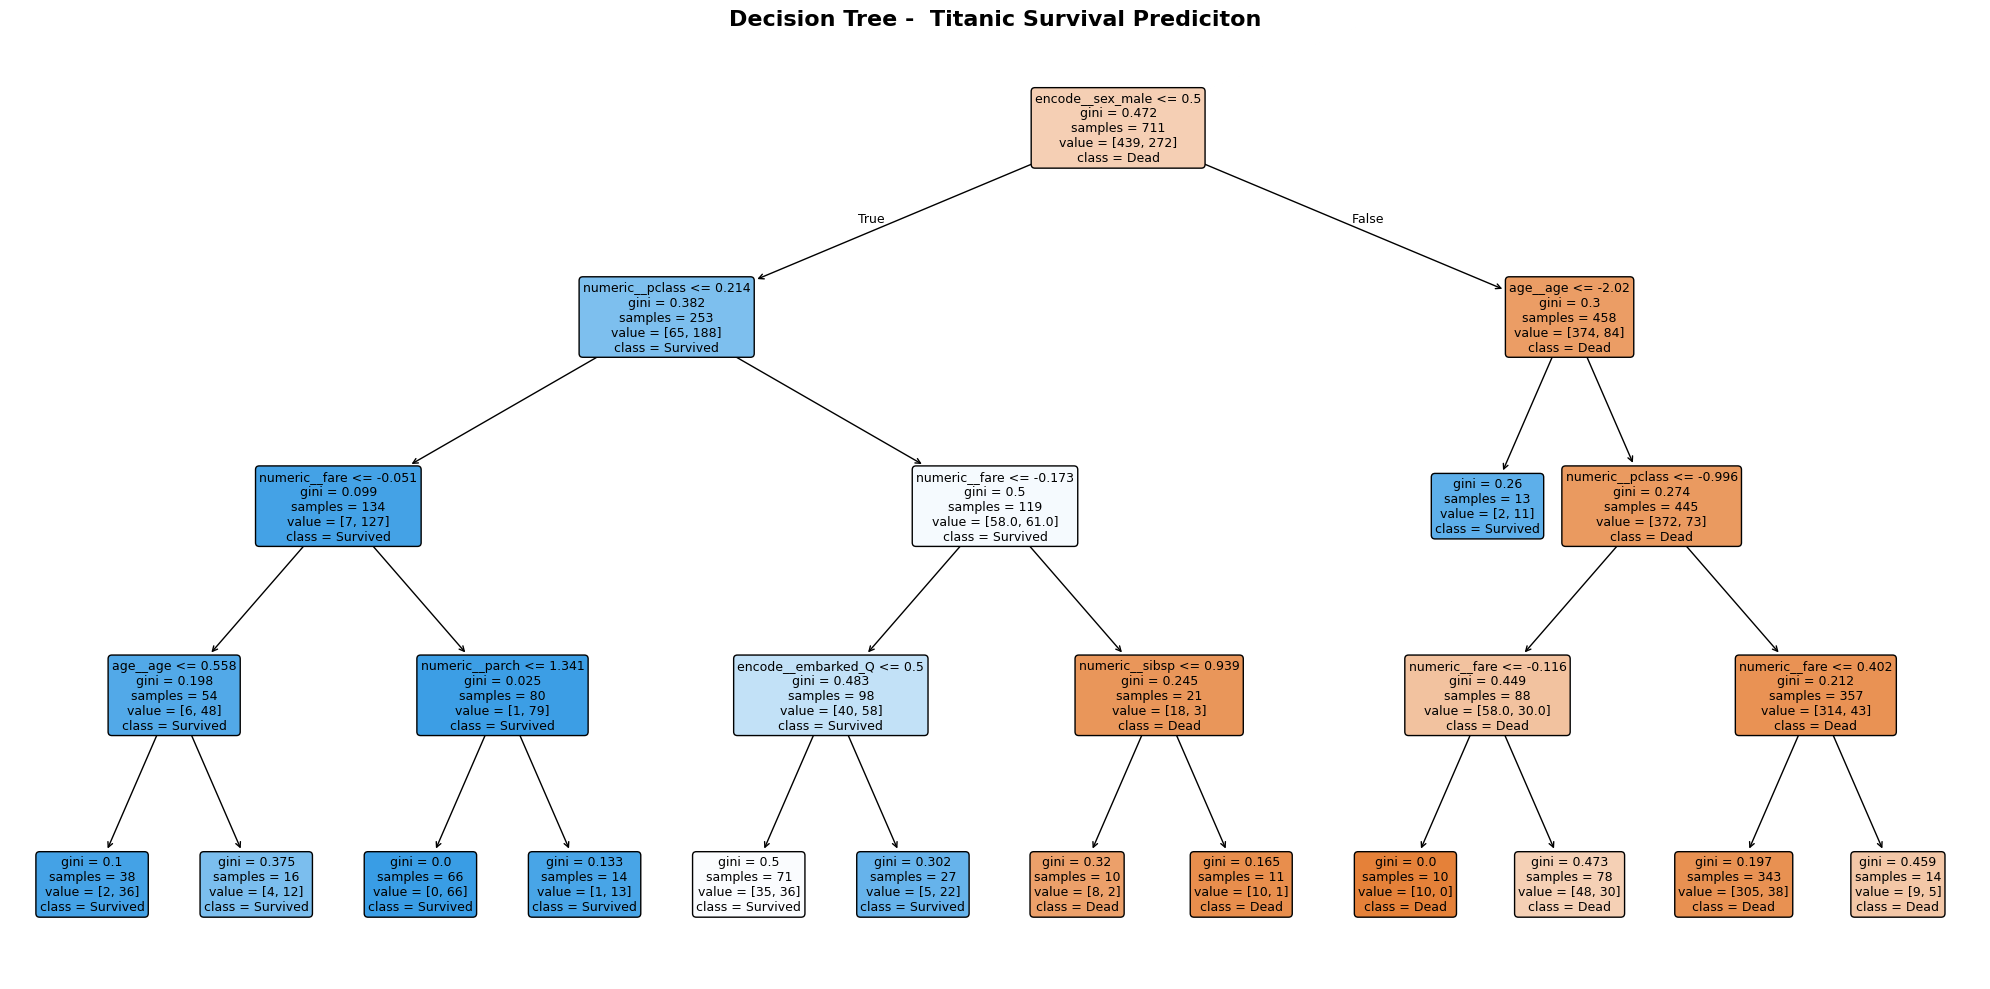

In [12]:
# plot tree for Decision tree classifier
import matplotlib.pyplot as plt



feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

fig, ax = plt.subplots(figsize = (20,10))
plot_tree(tree_model,
          feature_names=feature_names,
          class_names= ['Dead','Survived'],
          filled = True, # Coloring the nodes by majortiy calss)
          rounded = True,
          fontsize = 9,
          ax = ax
          )
ax.set_title("Decision Tree -  Titanic Survival Prediciton",
             fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.savefig("charts/decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

# Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier

rand_fore = RandomForestClassifier(
    n_estimators = 200, # Number of trees that we are building
    max_depth = None, # letting trees grow deep
    max_features = 'sqrt', # square root of n features per split.
    random_state = 42,
    n_jobs = -1, # You are saying that need to do parallel processing
)

rand_fore.fit(X_train_transformed,y_train)

y_test_pred_forest = rand_fore.predict(X_test_transformed)
y_test_proba_forest = rand_fore.predict_proba(X_test_transformed)[:,1]

# Logistis-Reg, Decision Tree, Random Forest Matrix comparision table

In [14]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve
)
results = []

def eva_scores(y_test_pred,y_test_proba,model):
  acc = accuracy_score(y_test,y_test_pred)
  prec = precision_score(y_test,y_test_pred)
  rec = recall_score(y_test,y_test_pred)
  f1 = f1_score(y_test,y_test_pred)
  auc_score = roc_auc_score(y_test, y_test_proba)
  cm = confusion_matrix(y_test,y_test_pred)

  results.append({
      'Model_name' : model,
      'Accuracy': f"{acc:.3f}",
      'Precision' : f"{prec:.3f}",
      'Recall' : f"{rec:.3f}",
      'F1-score': f"{f1:.3f}",
      'AUC_score' : f"{auc_score:.3f}",
      'Confusion Matrix': str(cm.tolist())
  })

# Logistic regression
eva_scores(y_test_pred_log,y_test_proba_log,"Logistic_reg")

# Decision Tree
eva_scores(y_test_pred_tree,y_test_proba_tree,"Decision_tree")

# Random Forest
eva_scores(y_test_pred_forest,y_test_proba_forest,"Random_forest")


comparision_table = pd.DataFrame(results)
comparision_table

,Model_name,Accuracy,Precision,Recall,F1-score,AUC_score,Confusion Matrix
0,Logistic_reg,0.820,0.800,0.706,0.750,0.865,"[[98, 12], [20, 48]]"
1,Decision_tree,0.798,0.776,0.662,0.714,0.853,"[[97, 13], [23, 45]]"
2,Random_forest,0.787,0.742,0.676,0.708,0.820,"[[94, 16], [22, 46]]"


# Plotting ROC-AUC curves

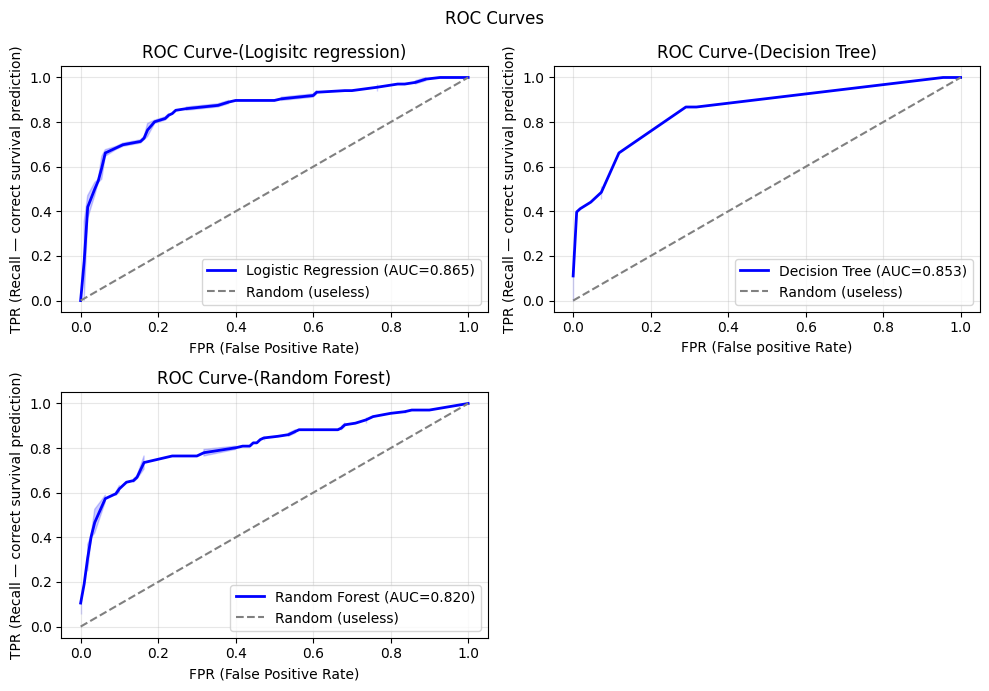

In [16]:
import seaborn as sns

fig,ax = plt.subplots(2,2,figsize=(10,7))

auc_1 = roc_auc_score(y_test, y_test_proba_log)
auc_2 = roc_auc_score(y_test, y_test_proba_tree)
auc_3 = roc_auc_score(y_test, y_test_proba_forest)

# Logistic Regression
# ax[0,0]

fpr_1,tpr_1,thresholds_1 = roc_curve(y_test,y_test_proba_log)
sns.lineplot(x = fpr_1, y = tpr_1, color='blue', linewidth=2, label=f'Logistic Regression (AUC={auc_1:.3f})',ax = ax[0,0])
ax[0,0].plot([0, 1], [0, 1], '--', color='grey', label='Random (useless)')
ax[0,0].set_xlabel('FPR (False Positive Rate)')
ax[0,0].set_ylabel('TPR (Recall — correct survival prediction)')
ax[0,0].set_title('ROC Curve-(Logisitc regression)')
ax[0,0].legend()
ax[0,0].grid(True, alpha=0.3)

# Decision Tree
# ax[0,1]

fpr_2,tpr_2,thresholds_2 = roc_curve(y_test,y_test_proba_tree)
sns.lineplot(x = fpr_2, y = tpr_2, color='blue', linewidth=2, label=f'Decision Tree (AUC={auc_2:.3f})',ax = ax[0,1])
ax[0,1].plot([0, 1], [0, 1], '--', color='grey', label='Random (useless)')
ax[0,1].set_xlabel('FPR (False positive Rate)')
ax[0,1].set_ylabel('TPR (Recall — correct survival prediction)')
ax[0,1].set_title('ROC Curve-(Decision Tree)')
ax[0,1].legend()
ax[0,1].grid(True, alpha=0.3)

# Random Forest
# ax[1,0]

fpr_3,tpr_3,thresholds_3 = roc_curve(y_test,y_test_proba_forest)
sns.lineplot(x = fpr_3, y = tpr_3, color='blue', linewidth=2, label=f'Random Forest (AUC={auc_3:.3f})',ax = ax[1,0])
ax[1,0].plot([0, 1], [0, 1], '--', color='grey', label='Random (useless)')
ax[1,0].set_xlabel('FPR (False Positive Rate)')
ax[1,0].set_ylabel('TPR (Recall — correct survival prediction)')
ax[1,0].set_title('ROC Curve-(Random Forest)')
ax[1,0].legend()
ax[1,0].grid(True, alpha=0.3)


plt.suptitle("ROC Curves")
fig.delaxes(ax[1,1])
plt.tight_layout()
plt.savefig("charts/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()


In [18]:
%pip install imbalanced-learn


   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-learn]

Note: you may need to restart the kernel to use updated packages.


# Imbalance handling comparison

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

#  Logistic Regression (baseline/no handling)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_transformed,y_train)

y_test_pred_log = log_reg.predict(X_test_transformed)
y_test_proba_log = log_reg.predict_proba(X_test_transformed)[:,1] # probabilities for 'class 1'

# Logistic Regression (Class_weight = "Balanced")

lr_balanced = LogisticRegression(max_iter=1000,
                                 random_state = 42,
                                 class_weight="balanced")
lr_balanced.fit(X_train_transformed,y_train)

y_pred_bal = lr_balanced.predict(X_test_transformed)
y_prob_bal = lr_balanced.predict_proba(X_test_transformed)[:,1]

# Logistic Regression (SMOTE oversampling)

smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_transformed,y_train)

lr_smote = LogisticRegression(max_iter= 1000, random_state = 42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test_transformed)
y_prob_smote = lr_smote.predict_proba(X_test_transformed)[:,1]


imbalance_matric_com = []

def imbalance_handling_comparision(y_test_pred,y_test_proba,model):
  acc = accuracy_score(y_test,y_test_pred)
  prec = precision_score(y_test,y_test_pred)
  rec = recall_score(y_test,y_test_pred)
  f1 = f1_score(y_test,y_test_pred)
  auc_score = roc_auc_score(y_test, y_test_proba)
  cm = confusion_matrix(y_test,y_test_pred)

  imbalance_matric_com.append({
      'Model_name' : model,
      'Precision' : f"{prec:.3f}",
      'Recall' : f"{rec:.3f}",
      'F1-score': f"{f1:.3f}",
  })

# Logistic regression
imbalance_handling_comparision(y_test_pred_log,y_test_proba_log,"Logistic_reg (Base model)")

# Logistic Regression (Class_weight = "Balanced")
imbalance_handling_comparision(y_pred_bal,y_prob_bal,"Logistic_reg (Class_weight = 'Balanced')")

# Logistic Regression (SMOTE oversampling)
imbalance_handling_comparision(y_pred_smote,y_prob_smote,"Logistic reg (SMOTE oversampling)")


imbalance_comparision = pd.DataFrame(imbalance_matric_com)
imbalance_comparision


,Model_name,Precision,Recall,F1-score
0,Logistic_reg (Base model),0.800,0.706,0.750
1,Logistic_reg (Class_weight = 'Balanced'),0.736,0.779,0.757
2,Logistic reg (SMOTE oversampling),0.754,0.765,0.759


# Imbalance Handling Conclusion:

The baseline Logistic Regression model achieved the highest precision (0.800) but had lower recall (0.706), indicating that it was more conservative in identifying the survived class. Using class_weight='balanced' improved recall to 0.779, but precision decreased to 0.736. SMOTE provided the best overall balance between precision (0.754) and recall (0.765), achieving the highest F1-score of 0.759. Therefore, SMOTE worked best for this dataset because it provided the best balance between correctly identifying survivors and avoiding incorrect survivor predictions.

# Hyperparameter tuning

In [20]:
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
)

rf = RandomForestClassifier(
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(rf,
                           param_grid,
                           cv=cv,
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose = 1)

grid_search.fit(X_train_transformed,y_train)

# Best model
best_rf = grid_search.best_estimator_

print(f"Best Parameters:\n{grid_search.best_params_}")

print(f"\nBest CV ROC-AUC Score: {round(grid_search.best_score_, 3)}")

print(f"\nOOB Score: {round(best_rf.oob_score_, 3)}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 200}

Best CV ROC-AUC Score: 0.875

OOB Score: 0.827


# Linear Regression

MAE        : 21.10
RMSE       : 41.70
R²         : 0.3482
Adjusted R²: 0.3008


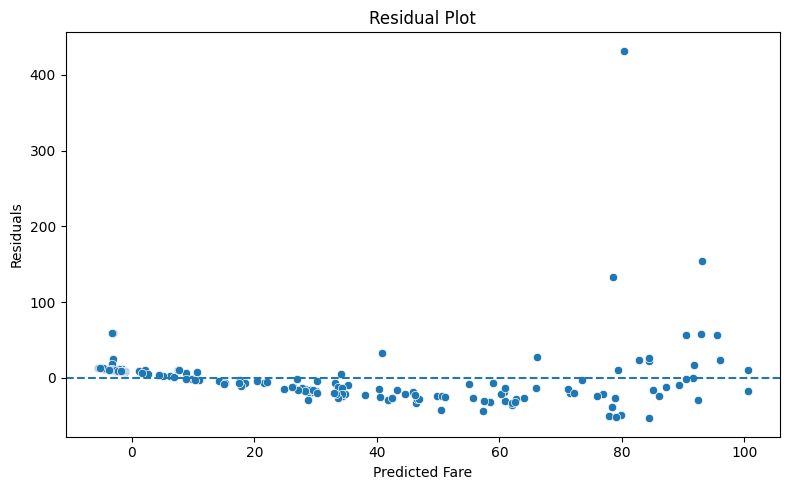

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import math

X_lr = df1.drop("fare", axis=1)
y_lr = df1["fare"]

X_train_lr,X_test_lr,y_train_lr,y_test_lr = train_test_split(X_lr,y_lr,test_size=0.2,random_state = 42)


preprocesor = ColumnTransformer(
    transformers=[
        ('age',Pipeline([
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())]),['age']),

        ('numeric',StandardScaler(),['pclass', 'sibsp', 'parch','survived']),

        ('encode',OneHotEncoder(handle_unknown='ignore'),['sex', 'embarked', 'alone'])],remainder='drop')

pipe_l = Pipeline([('preprocessor', preprocesor)])


X_train_transformed_lr = pipe_l.fit_transform(X_train_lr)
X_test_transformed_lr = pipe_l.transform(X_test_lr)


linear_model = LinearRegression()
linear_model.fit(X_train_transformed_lr,y_train_lr)

y_pred = linear_model.predict(X_test_transformed_lr)

# evalution Matrices

mae = mean_absolute_error(y_test_lr,y_pred)
mse = mean_squared_error(y_test_lr,y_pred)
rmse = np.sqrt(mse)

r2= r2_score(y_test_lr,y_pred)

n = X_test_transformed_lr.shape[0]
p = X_test_transformed_lr.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)


# 10. Print metrics
print(f"MAE        : {mae:.2f}")
print(f"RMSE       : {rmse:.2f}")
print(f"R²         : {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")

# 11. Residuals
residuals = y_test_lr - y_pred

# 12. Residual plot
plt.figure(figsize=(8, 5))

sns.scatterplot(x = y_pred, y = residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.savefig("charts/residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Logistic Regression conclusion

The multivariate linear regression model achieved an MAE of 21.10, an RMSE of 41.70, an R² of 0.3482, and an Adjusted R² of 0.3008. The R² indicates that the model explains approximately 34.82% of the variation in fare. The residual plot shows evidence of heteroscedasticity because the spread of residuals increases as the predicted fare increases. Several large residuals are also visible at higher predicted fare values, suggesting the presence of outliers and that a simple linear model does not fully capture the variation in fare.

# model comparison table

In [22]:
models_comparision = comparision_table.copy()

# Remove confusion matrix first
models_comparision = models_comparision.drop(
    columns='Confusion Matrix'
)

# Add Linear Regression as row 3
models_comparision.loc[3, 'Model_name'] = 'Linear Regression'

# Classification metrics are not applicable to regression
models_comparision.loc[3, 'Accuracy'] = '-'
models_comparision.loc[3, 'Precision'] = '-'
models_comparision.loc[3, 'Recall'] = '-'
models_comparision.loc[3, 'F1-score'] = '-'
models_comparision.loc[3, 'AUC_score'] = '-'

# Regression metrics
models_comparision['MAE'] = ['-', '-', '-', 21.10]
models_comparision['RMSE'] = ['-', '-', '-', 41.70]
models_comparision['R²'] = ['-', '-', '-', 0.3482]
models_comparision['Adjusted R²'] = ['-', '-', '-', 0.3008]

# Rename columns
models_comparision = models_comparision.rename(
    columns={
        'F1-score': 'F1',
        'AUC_score': 'AUC'
    }
)

models_comparision

,Model_name,Accuracy,Precision,Recall,F1,AUC,MAE,RMSE,R²,Adjusted R²
0,Logistic_reg,0.820,0.800,0.706,0.750,0.865,-,-,-,-
1,Decision_tree,0.798,0.776,0.662,0.714,0.853,-,-,-,-
2,Random_forest,0.787,0.742,0.676,0.708,0.820,-,-,-,-
3,Linear Regression,-,-,-,-,-,21.1,41.7,0.3482,0.3008


In [24]:
print(f"Final Model Recommendation\n\n")

print(f"Among the three classification models, Logistic Regression is recommended \nfor deployment because it achieved the highest accuracy of {models_comparision.loc[0,'Accuracy']}, precision of {models_comparision.loc[0,'Precision']},\n and AUC of {models_comparision.loc[0,'AUC']}. It also achieved the highest F1-score of {models_comparision.loc[0,'F1']} among the three\n classifiers, while its recall of 0.706 was higher than both Decision Tree and\n Random Forest. Although Random Forest achieved a slightly higher recall of {models_comparision.loc[0,'Recall']} \nthan Decision Tree at 0.662, neither model outperformed Logistic Regression overall.\nTherefore,Logistic Regression provides the best overall predictive performance and is the preferred classifier for deployment.")

Final Model Recommendation


Among the three classification models, Logistic Regression is recommended 
for deployment because it achieved the highest accuracy of 0.820, precision of 0.800,
 and AUC of 0.865. It also achieved the highest F1-score of 0.750 among the three
 classifiers, while its recall of 0.706 was higher than both Decision Tree and
 Random Forest. Although Random Forest achieved a slightly higher recall of 0.706 
than Decision Tree at 0.662, neither model outperformed Logistic Regression overall.
Therefore,Logistic Regression provides the best overall predictive performance and is the preferred classifier for deployment.


# Save complete pipeline

In [25]:
import joblib
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create complete pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Fit on RAW training data
full_pipeline.fit(X_train, y_train)

# Save complete pipeline
joblib.dump(
    full_pipeline,
    'titanic_survival_pipeline.joblib'
)

print("Complete pipeline saved successfully.")

# Reload saved pipeline
loaded_pipeline = joblib.load(
    'titanic_survival_pipeline.joblib'
)

print("Pipeline loaded successfully.")

# Predict using RAW test data
y_pred_original = full_pipeline.predict(X_test)
y_pred_loaded = loaded_pipeline.predict(X_test)

# Confirm predictions are identical
print("\nPredictions identical:",
      np.array_equal(y_pred_original, y_pred_loaded))

# Confirm accuracy
loaded_accuracy = accuracy_score(
    y_test,
    y_pred_loaded
)

print(f"Loaded pipeline accuracy: {loaded_accuracy:.3f}")

Complete pipeline saved successfully.
Pipeline loaded successfully.

Predictions identical: True
Loaded pipeline accuracy: 0.820
